Guardado: fig_mlp_var_full.pdf / .png
Guardado: fig_panel_4models.pdf / .png
Guardado: fig_zoom_covid.pdf / .png


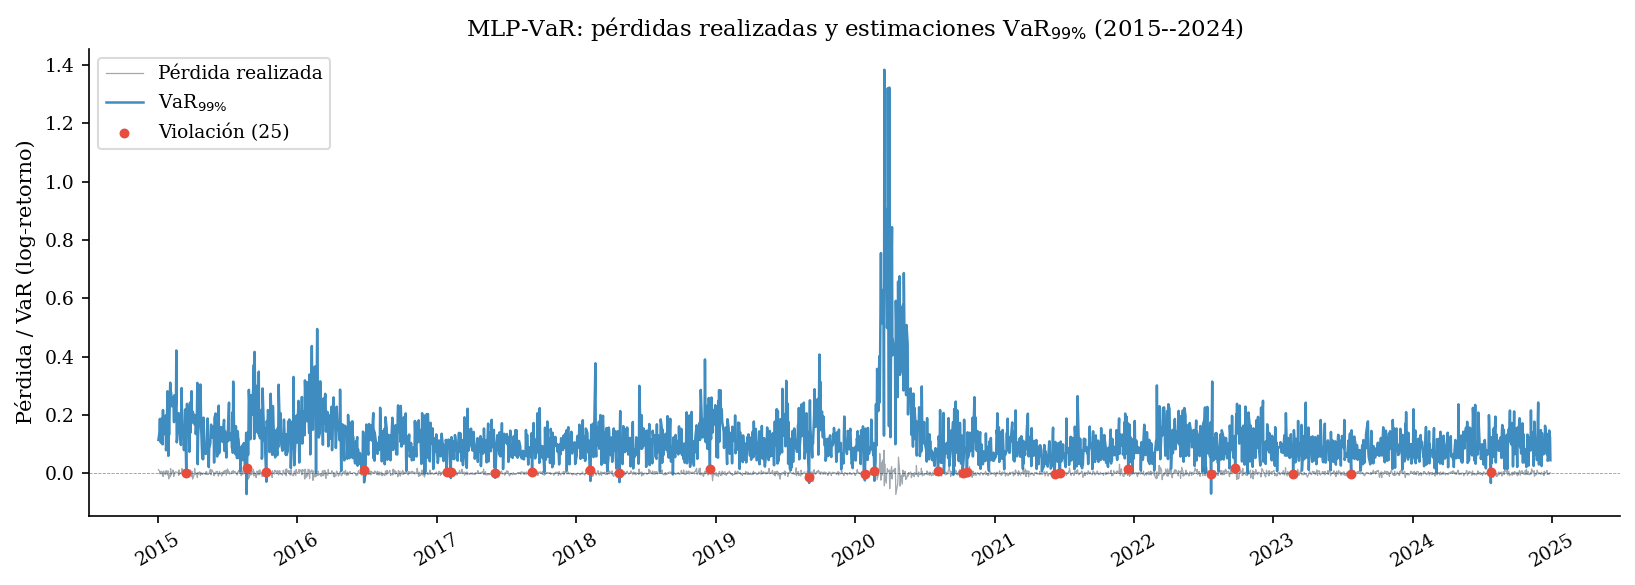

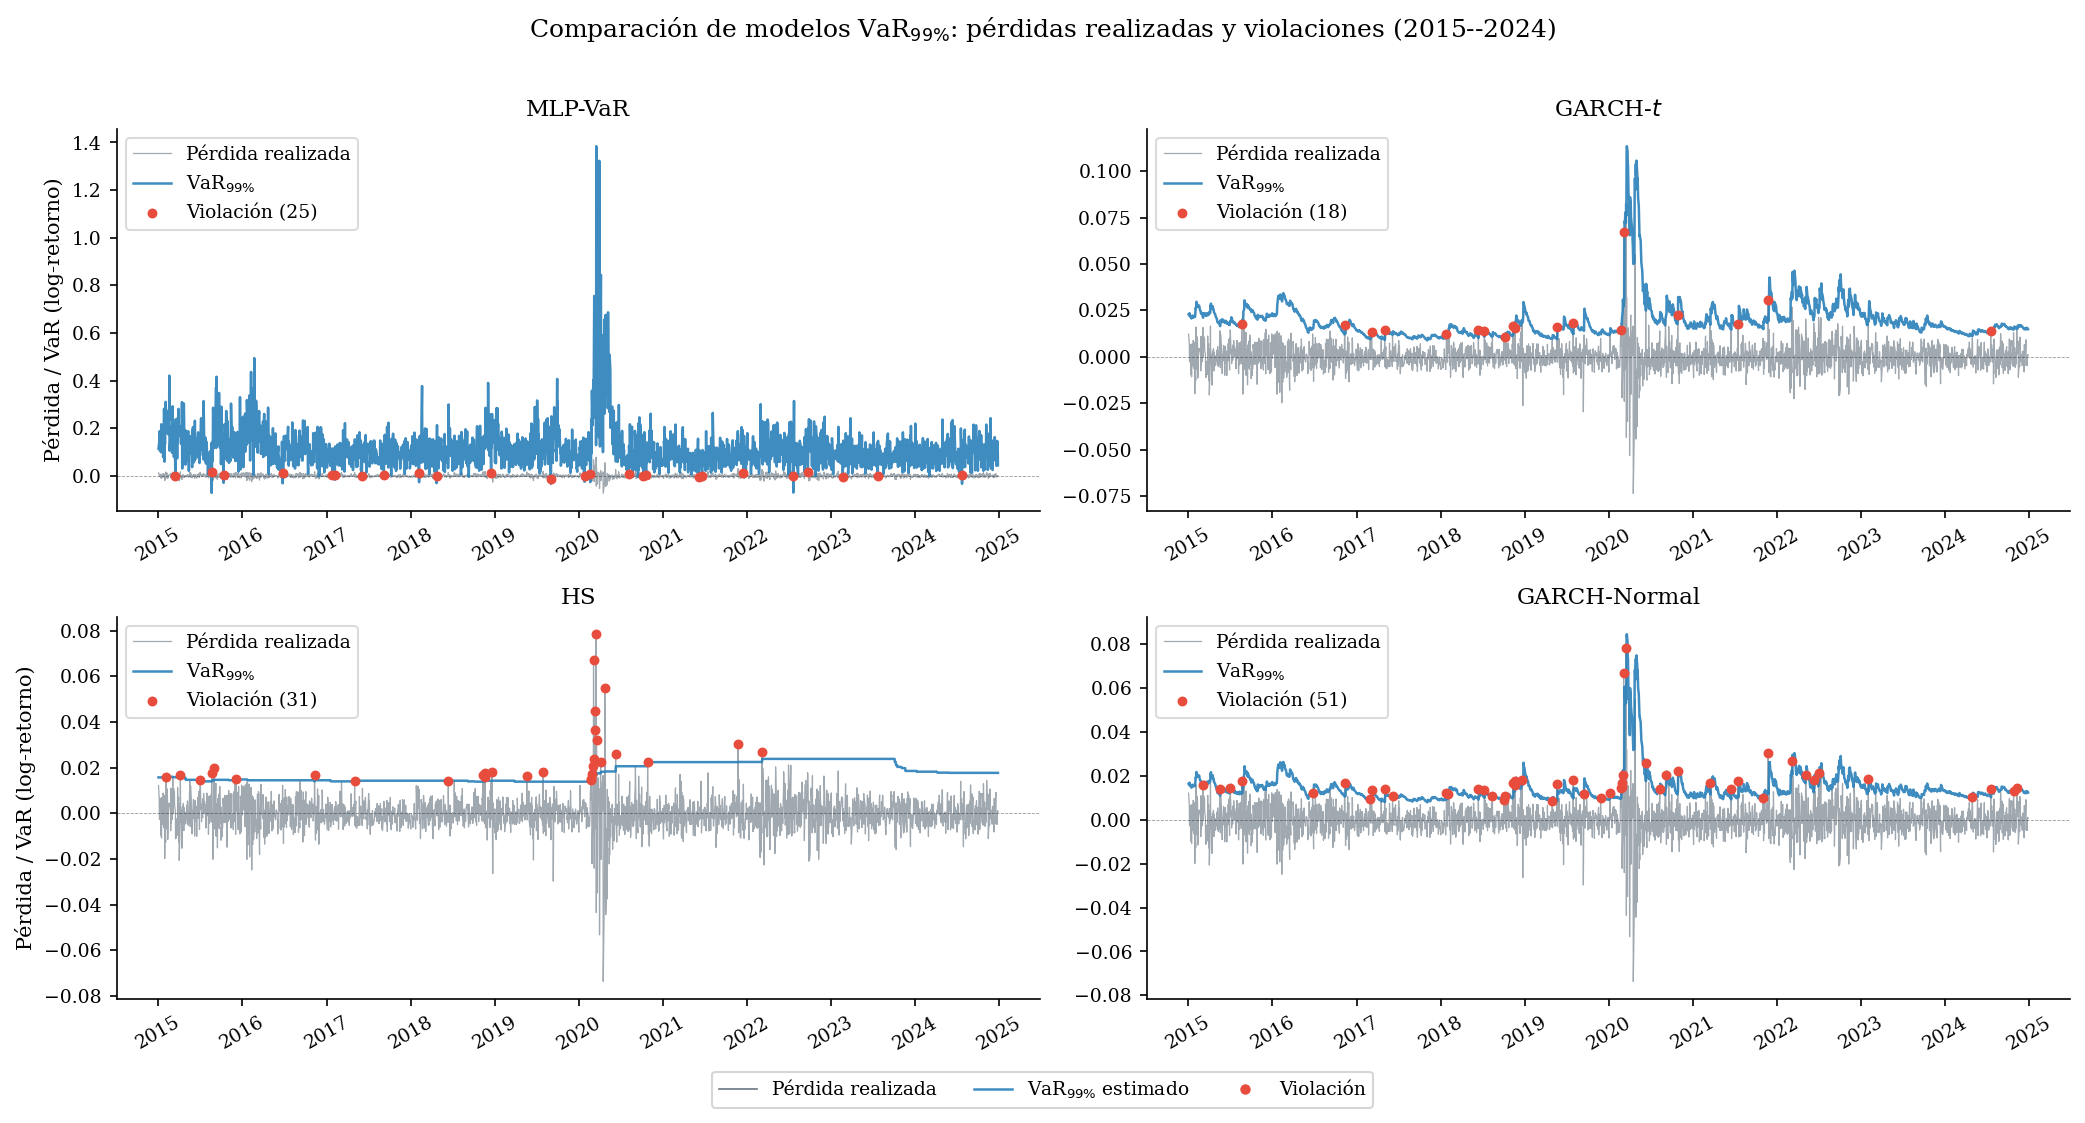

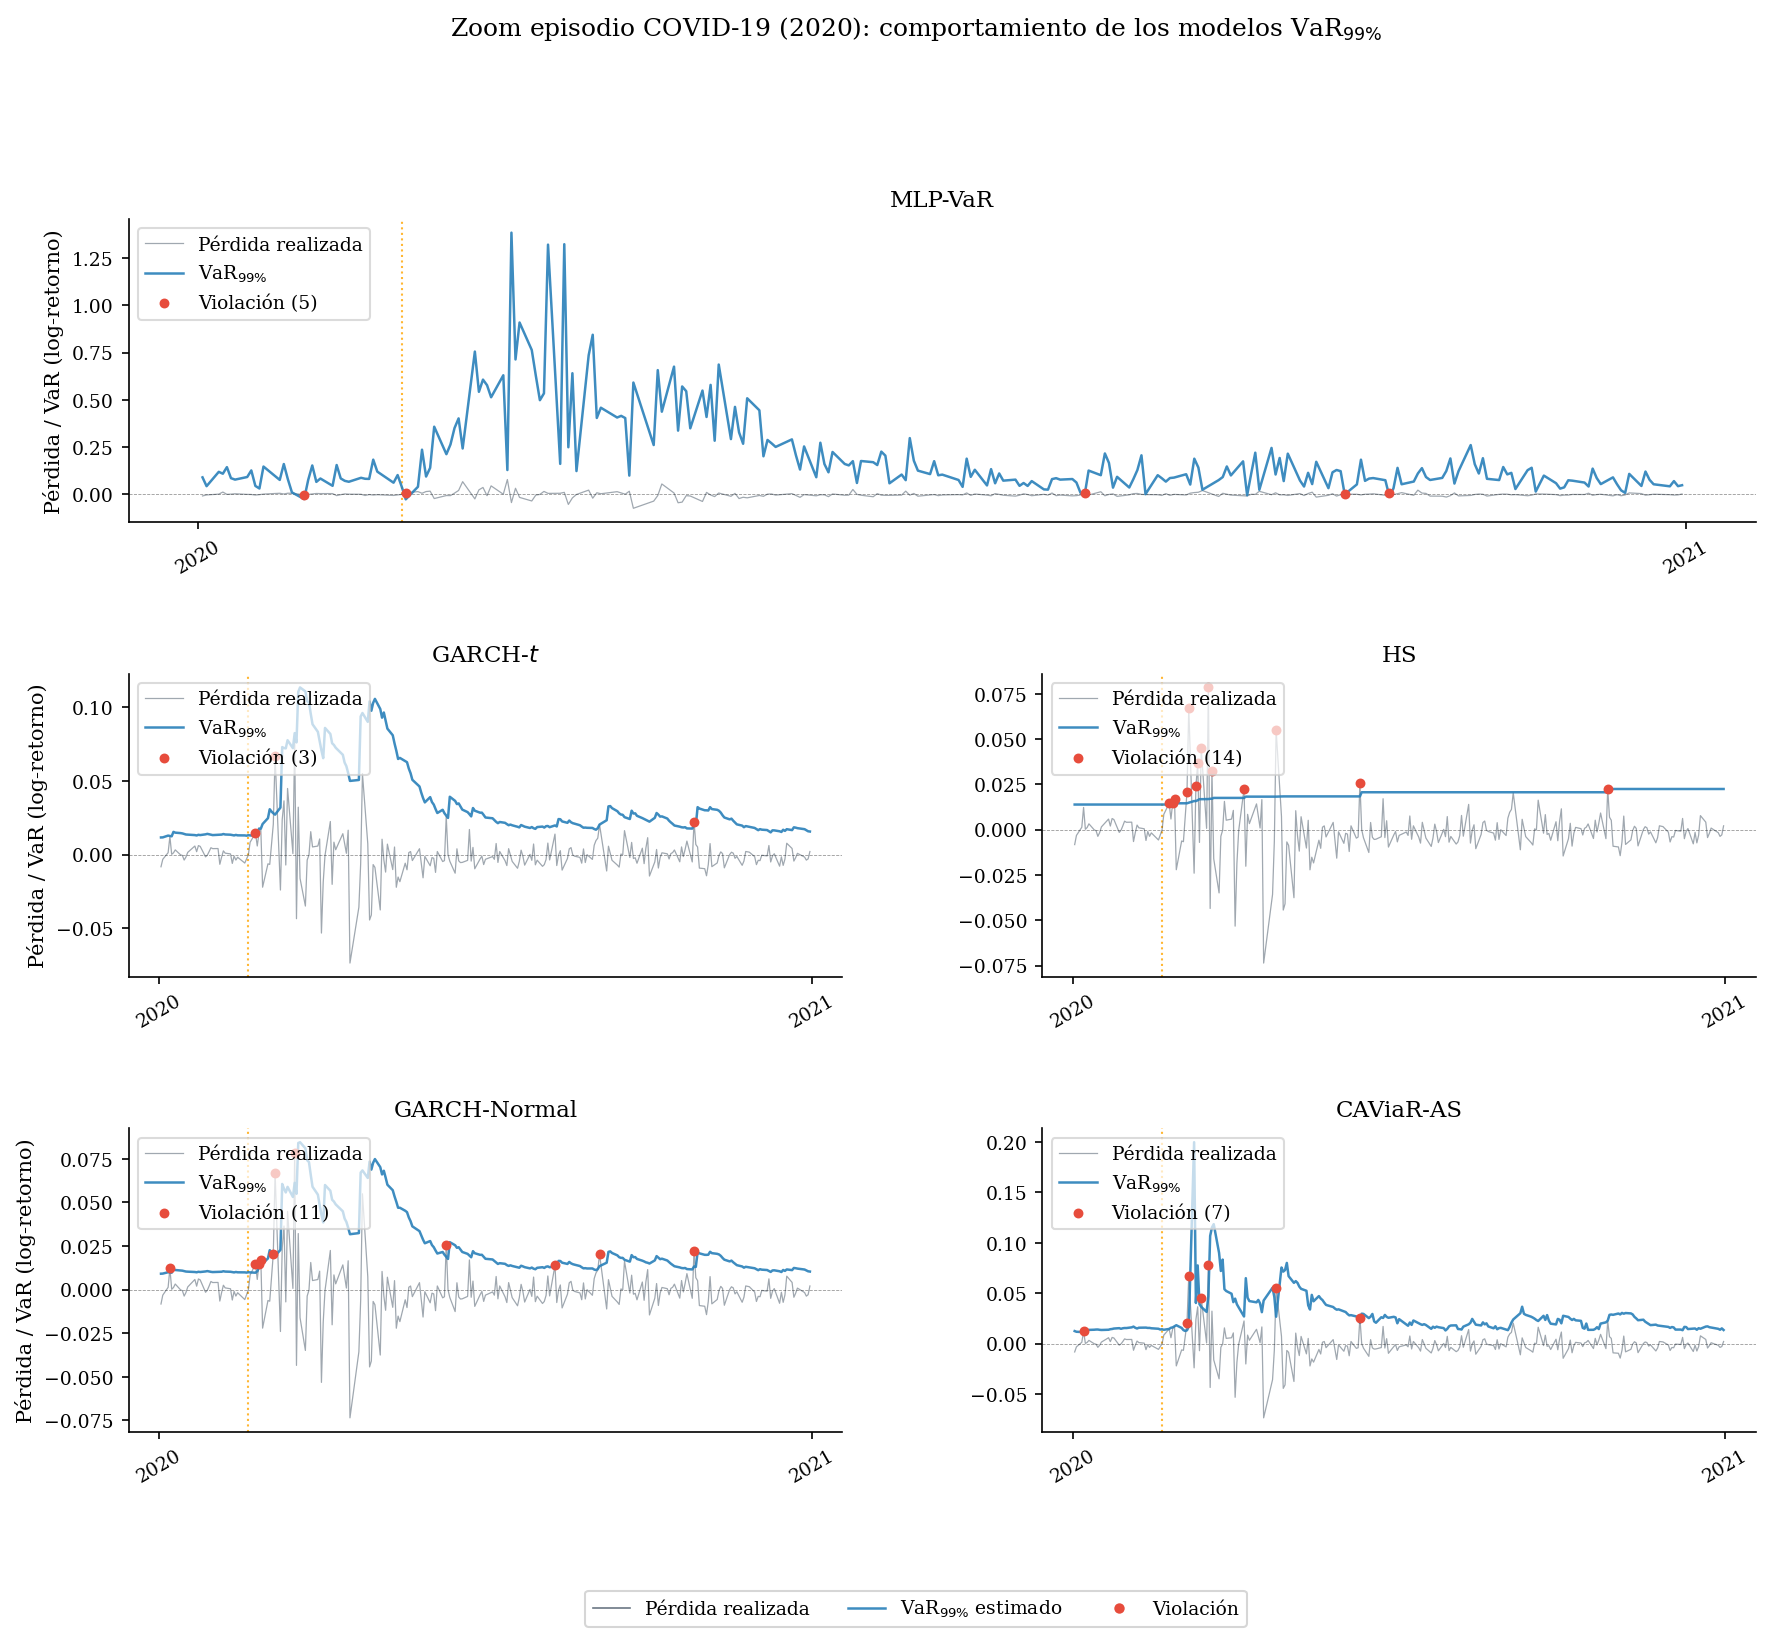

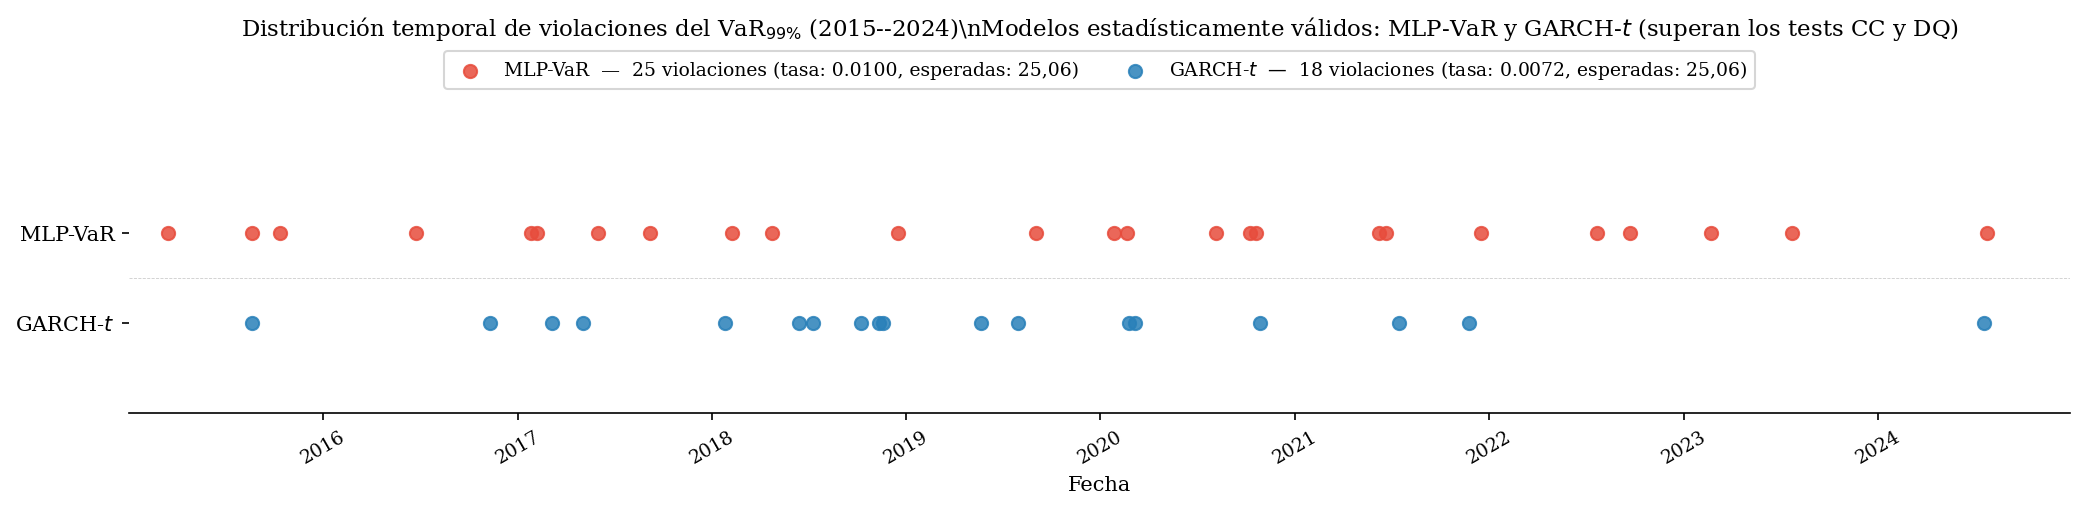

\nFiguras generadas correctamente.
Archivos producidos:
  fig_mlp_var_full.pdf / .png
  fig_panel_4models.pdf / .png
  fig_zoom_covid.pdf / .png
  fig_violaciones_temporales.pdf / .png


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from matplotlib.lines import Line2D

# =========================================================
# CARGA DE DATOS
# =========================================================

nn     = pd.read_csv("../data/nn_var_predictions_20.csv",      index_col=0, parse_dates=True)
hs     = pd.read_csv("../data/hs_var_predictions.csv",          index_col=0, parse_dates=True)
ga_t   = pd.read_csv("../data/garch_t_var_predictions.csv",     index_col=0, parse_dates=True)
ga_n   = pd.read_csv("../data/garch_n_var_predictions.csv",     index_col=0, parse_dates=True)
caviar = pd.read_csv("../data/caviar_var_predictions.csv",       index_col=0, parse_dates=True)

idx = (nn.index.intersection(hs.index)
               .intersection(ga_t.index)
               .intersection(ga_n.index)
               .intersection(caviar.index))
nn, hs, ga_t, ga_n, caviar = (nn.loc[idx], hs.loc[idx], ga_t.loc[idx],
                               ga_n.loc[idx], caviar.loc[idx])

data = {
    "MLP-VaR":      {"loss": nn["loss_real"].values,
                     "var":  nn["VaR_pred"].values,
                     "dates": nn.index},
    "HS":           {"loss": hs["loss_real"].values,
                     "var":  hs["VaR_HS"].values,
                     "dates": hs.index},
    "GARCH-$t$":    {"loss": ga_t["loss_real"].values,
                     "var":  ga_t["VaR_GARCH"].values,
                     "dates": ga_t.index},
    "GARCH-Normal": {"loss": ga_n["loss_real"].values,
                     "var":  ga_n["VaR_GARCH_n"].values,
                     "dates": ga_n.index},
    "CAViaR-AS":    {"loss": caviar["loss_real"].values,
                     "var":  caviar["VaR_CAViaR"].values,
                     "dates": caviar.index},
}

# =========================================================
# ESTILO GLOBAL
# =========================================================

plt.rcParams.update({
    "font.family":       "serif",
    "font.size":         10,
    "axes.titlesize":    11,
    "axes.labelsize":    10,
    "xtick.labelsize":   9,
    "ytick.labelsize":   9,
    "legend.fontsize":   9,
    "figure.dpi":        150,
    "axes.spines.top":   False,
    "axes.spines.right": False,
})

LOSS_COLOR = "#2c3e50"
VAR_COLOR  = "#2980b9"
VIOL_COLOR = "#e74c3c"
ALPHA_LOSS = 0.45
ALPHA_VAR  = 0.90


def plot_single(ax, dates, loss, var, title, show_ylabel=True):
    I = loss > var
    ax.plot(dates, loss, color=LOSS_COLOR, lw=0.6, alpha=ALPHA_LOSS,
            zorder=2, label="Pérdida realizada")
    ax.plot(dates, var,  color=VAR_COLOR,  lw=1.2, alpha=ALPHA_VAR,
            zorder=3, label="VaR$_{99\\%}$")
    ax.scatter(dates[I], loss[I], color=VIOL_COLOR, s=14, zorder=5,
               label=f"Violación ({I.sum()})")
    ax.axhline(0, color="black", lw=0.4, ls="--", alpha=0.4)
    ax.set_title(title, pad=6)
    if show_ylabel:
        ax.set_ylabel("Pérdida / VaR (log-retorno)")
    ax.xaxis.set_major_locator(mdates.YearLocator())
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
    ax.tick_params(axis="x", rotation=30)
    ax.legend(loc="upper left", framealpha=0.7)


legend_elements = [
    Line2D([0], [0], color=LOSS_COLOR, lw=0.8, alpha=0.7,
           label="Pérdida realizada"),
    Line2D([0], [0], color=VAR_COLOR,  lw=1.2, alpha=0.9,
           label="VaR$_{99\\%}$ estimado"),
    Line2D([0], [0], marker="o", color="w", markerfacecolor=VIOL_COLOR,
           markersize=6, label="Violación"),
]


# =========================================================
# FIGURA 1 — MLP-VaR completo (2015-2024)
# =========================================================

fig1, ax1 = plt.subplots(figsize=(11, 4))
d = data["MLP-VaR"]
plot_single(ax1, d["dates"], d["loss"], d["var"],
            title="MLP-VaR: pérdidas realizadas y estimaciones "
                  "VaR$_{99\\%}$ (2015--2024)")
fig1.tight_layout()
fig1.savefig("../figures/fig_mlp_var_full.pdf", bbox_inches="tight")
fig1.savefig("../figures/fig_mlp_var_full.png", bbox_inches="tight")
print("Guardado: fig_mlp_var_full.pdf / .png")


# =========================================================
# FIGURA 2 — Panel 2x2 con los cuatro modelos clásicos
# =========================================================

model_order = ["MLP-VaR", "GARCH-$t$", "HS", "GARCH-Normal"]

fig2, axes2 = plt.subplots(2, 2, figsize=(14, 7),
                            sharex=False, sharey=False)
axes2 = axes2.flatten()

for i, name in enumerate(model_order):
    d = data[name]
    plot_single(axes2[i], d["dates"], d["loss"], d["var"],
                title=name, show_ylabel=(i % 2 == 0))

fig2.suptitle(
    "Comparación de modelos VaR$_{99\\%}$: pérdidas realizadas "
    "y violaciones (2015--2024)",
    fontsize=12, y=1.01
)
fig2.legend(handles=legend_elements, loc="lower center",
            ncol=3, framealpha=0.8, bbox_to_anchor=(0.5, -0.04))
fig2.tight_layout()
fig2.savefig("../figures/fig_panel_4models.pdf", bbox_inches="tight")
fig2.savefig("../figures/fig_panel_4models.png", bbox_inches="tight")
print("Guardado: fig_panel_4models.pdf / .png")


# =========================================================
# FIGURA 3 — Zoom COVID-19: enero 2020 - diciembre 2020
#            MLP-VaR arriba (ancho completo)
#            GARCH-t | HS  (fila 2)
#            GARCH-N | CAViaR-AS (fila 3)
# =========================================================

covid_start = pd.Timestamp("2020-01-01")
covid_end   = pd.Timestamp("2020-12-31")

bottom_models = ["GARCH-$t$", "HS", "GARCH-Normal", "CAViaR-AS"]

fig3 = plt.figure(figsize=(14, 10.5))
gs   = fig3.add_gridspec(3, 2, hspace=0.50, wspace=0.28)

ax_top  = fig3.add_subplot(gs[0, :])
ax_bot  = [fig3.add_subplot(gs[1 + r, c]) for r in range(2) for c in range(2)]

# Panel superior — MLP-VaR
d    = data["MLP-VaR"]
mask = (d["dates"] >= covid_start) & (d["dates"] <= covid_end)
plot_single(ax_top, d["dates"][mask], d["loss"][mask], d["var"][mask],
            title="MLP-VaR", show_ylabel=True)
ax_top.axvline(pd.Timestamp("2020-02-20"), color="orange",
               lw=1.0, ls=":", alpha=0.8, zorder=1)

# Paneles inferiores — 4 modelos en 2×2
for ax, name in zip(ax_bot, bottom_models):
    d    = data[name]
    mask = (d["dates"] >= covid_start) & (d["dates"] <= covid_end)
    show_y = (ax is ax_bot[0]) or (ax is ax_bot[2])
    plot_single(ax, d["dates"][mask], d["loss"][mask], d["var"][mask],
                title=name, show_ylabel=show_y)
    ax.axvline(pd.Timestamp("2020-02-20"), color="orange",
               lw=1.0, ls=":", alpha=0.8, zorder=1)

fig3.suptitle(
    "Zoom episodio COVID-19 (2020): comportamiento de los modelos "
    "VaR$_{99\\%}$",
    fontsize=12, y=1.01
)
fig3.legend(handles=legend_elements, loc="lower center",
            ncol=3, framealpha=0.8, bbox_to_anchor=(0.5, -0.02))
fig3.savefig("../figures/fig_zoom_covid.pdf", bbox_inches="tight")
fig3.savefig("../figures/fig_zoom_covid.png", bbox_inches="tight")
print("Guardado: fig_zoom_covid.pdf / .png")


# =========================================================
# FIGURA 4 — Distribución temporal de violaciones
#            Solo modelos estadísticamente válidos:
#            MLP-VaR (supera CC y DQ) y GARCH-t (supera CC y DQ)
# =========================================================

valid_models  = ["MLP-VaR", "GARCH-$t$"]
marker_colors = {"MLP-VaR": "#e74c3c", "GARCH-$t$": "#2980b9"}
marker_y      = {"MLP-VaR": 1.1, "GARCH-$t$": 0.9}
labels_y      = {"MLP-VaR": 1.18, "GARCH-$t$": 0.82}

fig4, ax4 = plt.subplots(figsize=(14, 3.5))

for name in valid_models:
    d           = data[name]
    mask_viol   = d["loss"] > d["var"]
    fechas_viol = d["dates"][mask_viol]
    n_viol      = mask_viol.sum()
    y_val       = marker_y[name]
    color       = marker_colors[name]

    ax4.scatter(fechas_viol,
                [y_val] * len(fechas_viol),
                color=color, s=40, zorder=5, alpha=0.85,
                label=f"{name}  —  {n_viol} violaciones "
                      f"(tasa: {n_viol / len(d['dates']):.4f}, "
                      f"esperadas: 25,06)")

ax4.set_xlim(data["MLP-VaR"]["dates"].min(),
             data["MLP-VaR"]["dates"].max())
ax4.set_ylim(0.7, 1.4)
ax4.set_yticks([0.9, 1.1])
ax4.set_yticklabels(["GARCH-$t$", "MLP-VaR"], fontsize=10)
ax4.xaxis.set_major_locator(mdates.YearLocator())
ax4.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
ax4.tick_params(axis="x", rotation=30)
ax4.set_xlabel("Fecha", fontsize=10)
ax4.spines["top"].set_visible(False)
ax4.spines["right"].set_visible(False)
ax4.spines["left"].set_visible(False)
ax4.axhline(1.0, color="grey", lw=0.4, ls="--", alpha=0.4)

ax4.legend(loc="upper center", framealpha=0.8,
           bbox_to_anchor=(0.5, 1.18), ncol=2, fontsize=9)

ax4.set_title(
    "Distribución temporal de violaciones del VaR$_{99\\%}$ (2015--2024)\\n"
    "Modelos estadísticamente válidos: MLP-VaR y GARCH-$t$ "
    "(superan los tests CC y DQ)",
    fontsize=11, pad=30
)

fig4.tight_layout()
fig4.savefig("../figures/fig_violaciones_temporales.pdf", bbox_inches="tight")
fig4.savefig("../figures/fig_violaciones_temporales.png", bbox_inches="tight")

plt.show()
print("\\nFiguras generadas correctamente.")
print("Archivos producidos:")
print("  fig_mlp_var_full.pdf / .png")
print("  fig_panel_4models.pdf / .png")
print("  fig_zoom_covid.pdf / .png")
print("  fig_violaciones_temporales.pdf / .png")